In [75]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy.stats
from tqdm.notebook import tqdm
from multiprocessing import Pool
from functools import partial
from scipy.stats import multivariate_normal 
import random
import matplotlib
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Activation, Flatten, Dense, MaxPooling1D, GlobalAveragePooling1D, AveragePooling1D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from keras import layers
from keras.utils import to_categorical
import tensorflow_addons as tfa
from tensorflow.keras.regularizers import l2



In [4]:
# AES sbox
sbox = np.array([
    0x63, 0x7C, 0x77, 0x7B, 0xF2, 0x6B, 0x6F, 0xC5, 0x30, 0x01, 0x67, 0x2B, 0xFE, 0xD7, 0xAB, 0x76,
    0xCA, 0x82, 0xC9, 0x7D, 0xFA, 0x59, 0x47, 0xF0, 0xAD, 0xD4, 0xA2, 0xAF, 0x9C, 0xA4, 0x72, 0xC0,
    0xB7, 0xFD, 0x93, 0x26, 0x36, 0x3F, 0xF7, 0xCC, 0x34, 0xA5, 0xE5, 0xF1, 0x71, 0xD8, 0x31, 0x15,
    0x04, 0xC7, 0x23, 0xC3, 0x18, 0x96, 0x05, 0x9A, 0x07, 0x12, 0x80, 0xE2, 0xEB, 0x27, 0xB2, 0x75,
    0x09, 0x83, 0x2C, 0x1A, 0x1B, 0x6E, 0x5A, 0xA0, 0x52, 0x3B, 0xD6, 0xB3, 0x29, 0xE3, 0x2F, 0x84,
    0x53, 0xD1, 0x00, 0xED, 0x20, 0xFC, 0xB1, 0x5B, 0x6A, 0xCB, 0xBE, 0x39, 0x4A, 0x4C, 0x58, 0xCF,
    0xD0, 0xEF, 0xAA, 0xFB, 0x43, 0x4D, 0x33, 0x85, 0x45, 0xF9, 0x02, 0x7F, 0x50, 0x3C, 0x9F, 0xA8,
    0x51, 0xA3, 0x40, 0x8F, 0x92, 0x9D, 0x38, 0xF5, 0xBC, 0xB6, 0xDA, 0x21, 0x10, 0xFF, 0xF3, 0xD2,
    0xCD, 0x0C, 0x13, 0xEC, 0x5F, 0x97, 0x44, 0x17, 0xC4, 0xA7, 0x7E, 0x3D, 0x64, 0x5D, 0x19, 0x73,
    0x60, 0x81, 0x4F, 0xDC, 0x22, 0x2A, 0x90, 0x88, 0x46, 0xEE, 0xB8, 0x14, 0xDE, 0x5E, 0x0B, 0xDB,
    0xE0, 0x32, 0x3A, 0x0A, 0x49, 0x06, 0x24, 0x5C, 0xC2, 0xD3, 0xAC, 0x62, 0x91, 0x95, 0xE4, 0x79,
    0xE7, 0xC8, 0x37, 0x6D, 0x8D, 0xD5, 0x4E, 0xA9, 0x6C, 0x56, 0xF4, 0xEA, 0x65, 0x7A, 0xAE, 0x08,
    0xBA, 0x78, 0x25, 0x2E, 0x1C, 0xA6, 0xB4, 0xC6, 0xE8, 0xDD, 0x74, 0x1F, 0x4B, 0xBD, 0x8B, 0x8A,
    0x70, 0x3E, 0xB5, 0x66, 0x48, 0x03, 0xF6, 0x0E, 0x61, 0x35, 0x57, 0xB9, 0x86, 0xC1, 0x1D, 0x9E,
    0xE1, 0xF8, 0x98, 0x11, 0x69, 0xD9, 0x8E, 0x94, 0x9B, 0x1E, 0x87, 0xE9, 0xCE, 0x55, 0x28, 0xDF,
    0x8C, 0xA1, 0x89, 0x0D, 0xBF, 0xE6, 0x42, 0x68, 0x41, 0x99, 0x2D, 0x0F, 0xB0, 0x54, 0xBB, 0x16
])

In [5]:
# Hamming Weight: nr. of 1's in binary of given int value. e.g. HW[0] = 0, HW[255] = 8
HW = np.array([bin(n).count("1") for n in range(0, 256)])

In [6]:
def snr(obs_value, traces):
    max_val = np.max(obs_value)
    means = [None] * (max_val + 1)
    varss = [None] * (max_val + 1)
    for i in range(max_val + 1):
        means[i] = np.mean(traces[obs_value == i], axis=0)
        varss[i] = np.var(traces[obs_value == i], axis=0)
    means = np.array(means)
    varss = np.array(varss)
    snr = np.zeros_like(means[0])
    u_tot = np.mean(means, axis=0)
    v_tot = np.mean(varss, axis=0)
    for i in range(max_val + 1):
        snr += np.power(means[i]-u_tot, 2)
    snr = snr / v_tot
    return snr


# Correlation Power Analysis

In [7]:
with h5py.File('/kaggle/input/pinata-sca/AES_PTv2_Pinata.h5', "r") as in_file:
    pt = np.array(in_file["Pinata/MS1/Attack/MetaData"]['plaintext'])
    key = np.array(in_file["Pinata/MS1/Attack/MetaData"]['key'])
    traces = np.array(in_file["Pinata/MS1/Attack/Traces"])

In [8]:
attack_byte = 2

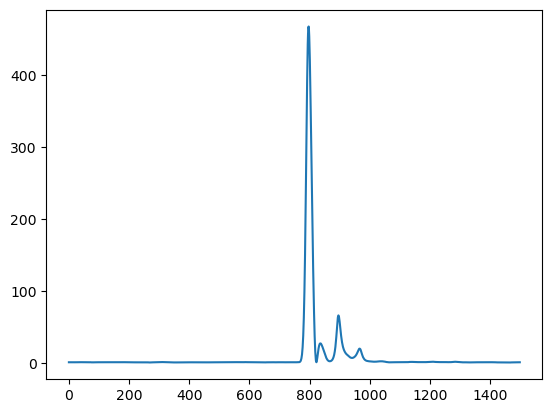

In [9]:
plt.plot(snr(sbox[pt[:,attack_byte]^key[:,attack_byte]], traces))

In [10]:
def partial_key(key_guess, attack_byte, pt, traces):
    hypotheses = np.array([HW[sbox[pt[i, attack_byte] ^ key_guess]] for i in range(pt.shape[0])])
    # we use the hypotheses and calculate the correlation
    return np.max(np.corrcoef(hypotheses, traces, rowvar=False)[0, 1:])

In [11]:
# we have traces, lets take the HW leakage model, now we can do a correlation-based attack
# for this we don't need to use the training dataset, it is an unprofiled attack model

key_vector = np.zeros(256)
print(f"analysing {traces.shape[0]} traces")
print(f"attacking byte {attack_byte}")
for kguess in tqdm(range(256)):
    key_vector[kguess] = partial_key(key_guess=kguess, attack_byte=attack_byte, pt=pt, traces=traces)
print(f"key hypothesis with highest correlation: {np.argmax(key_vector)}, correct key: {key[0][attack_byte]}")

analysing 50000 traces
attacking byte 2


  0%|          | 0/256 [00:00<?, ?it/s]

key hypothesis with highest correlation: 186, correct key: 186


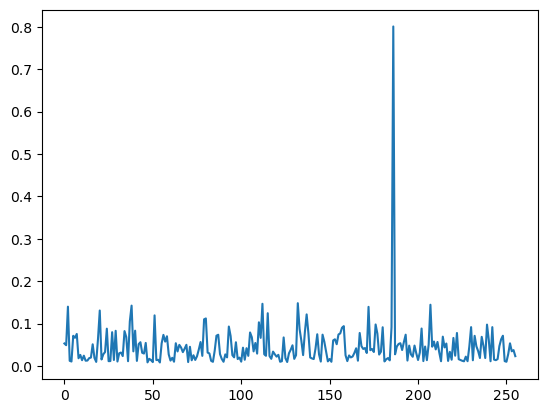

In [12]:
plt.plot(key_vector)

In [18]:
# with Pool() as pool:
#     key_vector = list(tqdm(pool.imap(partial(partial_key, attack_byte=attack_byte, pt=pt, traces=traces), range(256)), total=256))
# print(f"key hypothesis with highest correlation: {np.argmax(key_vector)}, correct key: {key[0][attack_byte]}")

# Differential Power Analysis

In [19]:
# exercise: write the code to do a differential power analysis below

In [13]:
key_vector = np.zeros(256)
print(f"analysing {traces.shape[0]} traces")
print(f"attacking byte {attack_byte}")

for kguess in tqdm(range(256)):
    #######
    ####### YOU ONLY NEED TO FILL IN THIS CODE INSIDE THE FOR-LOOP
    #######
    # make the hypotheses of the leaking value based on the key
    hypotheses = sbox[pt[:, attack_byte] ^ kguess] & 1
    # split the traces into 2 groups based on the LSB of the hypotheses, and calculate the point-wise mean of each
    lsb_0 = traces[hypotheses ==0]
    lsb_1 = traces[hypotheses ==1]
    # calculate the point-wise absolute difference between the 2 groups
    diff = np.abs(np.mean(lsb_0) - np.mean(lsb_1))
    # estimate the probability / likelihood of this keyguess as the maximum absolute point-wise difference between the groups
    key_vector[kguess] = np.max(diff)

    
print(f"key hypothesis with highest DoM: {np.argmax(key_vector)}, correct key: {key[0][attack_byte]}")

analysing 50000 traces
attacking byte 2


  0%|          | 0/256 [00:00<?, ?it/s]

key hypothesis with highest DoM: 85, correct key: 186


# Template attack
Now we will run a template attack which is a type of profiled attack. It is quite simple in the sense that you build a multivariate normal distribution for each hamming weight. Then in the attacking stage you use these distributions to estimate the likelihood of your hypotheses.

In [21]:
with h5py.File('/kaggle/input/pinata-sca/AES_PTv2_Pinata.h5', "r") as in_file:
    traces_prof = np.array(in_file["Pinata/Unprotected/Profiling/Traces"])
    traces_attack = np.array(in_file["Pinata/Unprotected/Attack/Traces"])
    
    pt_prof = np.array(in_file["Pinata/Unprotected/Profiling/MetaData"]['plaintext'])
    pt_attack = np.array(in_file["Pinata/Unprotected/Attack/MetaData"]['plaintext'])
    
    key_prof = np.array(in_file["Pinata/Unprotected/Profiling/MetaData"]['key'])
    key_attack = np.array(in_file["Pinata/Unprotected/Attack/MetaData"]['key'])

In [22]:
attack_byte=2

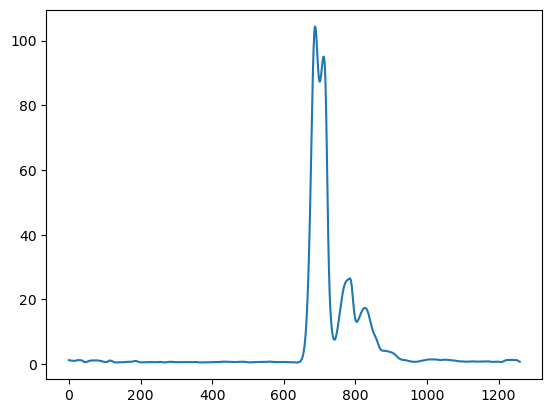

In [23]:
# First we need to do PoI selection
snr_prof = snr(sbox[pt_prof[:,attack_byte]^key_prof[:,attack_byte]], traces_prof)
plt.plot(snr_prof)

# just take a window of 30 around the point of maximum leakage
window = (np.argmax(snr_prof)- 20, np.argmax(snr_prof) + 20)

In [24]:
traces_hw = np.array([traces_prof[HW[sbox[pt_prof[:, attack_byte] ^ key_prof[:,attack_byte]]] == hw, window[0]:window[1]] for hw in range(9)], dtype=object)
for hw in range(9):
    print(f"traces with hw {hw}: {traces_hw[hw].shape[0]}")

traces with hw 0: 382
traces with hw 1: 3093
traces with hw 2: 10827
traces with hw 3: 21882
traces with hw 4: 27480
traces with hw 5: 21855
traces with hw 6: 10921
traces with hw 7: 3164
traces with hw 8: 396


In [25]:
mean_mat = np.array([np.mean(traces_hw[hw], axis=0) for hw in range(9)])
cov_mat = np.array([np.cov(traces_hw[hw], rowvar=False) for hw in range(9)])

In [26]:
# we have built a multivariate normal distribution for each HW based on the profiling dataset, i.e. we have our model
# we can now run the attack on the attack dataset
key_vector = np.zeros(256)

# note: we only need to use 10 traces in our attack now
for i in tqdm(range(10)):
    for kguess in range(256):
        hypothesis = HW[sbox[pt_attack[i, attack_byte] ^ kguess]]
        distr = multivariate_normal(mean=mean_mat[hypothesis], cov=cov_mat[hypothesis])
        p_k = distr.pdf(traces_attack[i, window[0]:window[1]])
        key_vector[kguess] += np.log(p_k)
        
print(f"key hypothesis with highest log-likelihood: {np.argmax(key_vector)}, correct key: {key_attack[0][attack_byte]}")

  0%|          | 0/10 [00:00<?, ?it/s]

key hypothesis with highest log-likelihood: 186, correct key: 186


# Using ML for SCA
We will now look at a protected implementation. Specifically, the implementation is masked.

In [14]:
attack_byte = 0

In [15]:
with h5py.File('/kaggle/input/pinata-sca/AES_PTv2_Pinata.h5', "r") as in_file:
    traces_prof = np.array(in_file["Pinata/MS1/Profiling/Traces"])
    traces_attack = np.array(in_file["Pinata/MS1/Attack/Traces"])
    
    pt_prof = np.array(in_file["Pinata/MS1/Profiling/MetaData"]['plaintext'])
    pt_attack = np.array(in_file["Pinata/MS1/Attack/MetaData"]['plaintext'])
    
    key_prof = np.array(in_file["Pinata/MS1/Profiling/MetaData"]['key'])
    key_attack = np.array(in_file["Pinata/MS1/Attack/MetaData"]['key'])

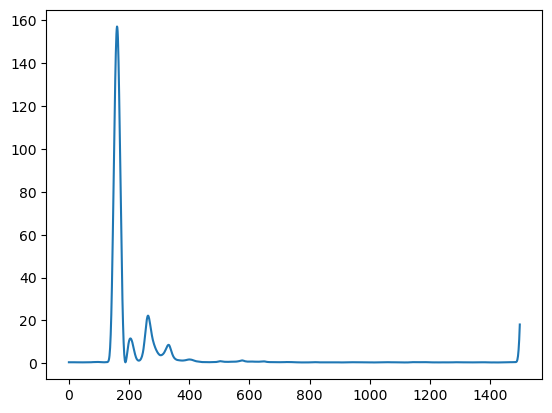

In [147]:
# the implementation is masked, but is it done correctly?
#no, there is a huge spike of snr,the trace is still correlated with the intermedian value
plt.plot(snr(sbox[pt_prof[:,attack_byte] ^ key_prof[:,attack_byte]], traces_prof))

In [16]:

with tf.device("GPU"):
    start = layers.Input(shape=(1500, 1))

    # Convolution layer
    x = layers.Conv1D(8, 16, kernel_initializer='he_uniform',
                      activation='selu', padding='same')(start)
    x = layers.MaxPool1D(2, strides=2)(x)
    x = layers.BatchNormalization()(x)

    # Flatten for dense layers
    x = layers.Flatten()(x)

    # Dense layers
    x = layers.Dense(400, kernel_initializer='he_uniform',
                     activation='selu')(x)

    x = layers.Dense(50, kernel_initializer='he_uniform',
                    activation='selu')(x)
    
    # Classification layer
    end = layers.Dense(9, activation='softmax',
                       name='predictions')(x)

    clr = tfa.optimizers.CyclicalLearningRate(initial_learning_rate=1e-5,
        maximal_learning_rate=1e-2,
        scale_fn=lambda x: 1/(2.**(x-1)),
        step_size=2 * traces_prof.shape[0]
    )

    model = tf.keras.models.Model(start, end)
    model.compile(loss='categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(clr),
                  metrics=['accuracy'])

In [17]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [20]:
tf.debugging.set_log_device_placement(True)
with tf.device('GPU'):
    model.fit(x=traces_prof, y=to_categorical(HW[sbox[pt_prof[:, attack_byte] ^ key_prof[:, attack_byte]]]),
                  batch_size=50, verbose=1,
                  epochs=40,
                  shuffle=True,
                  callbacks=[early_stopping],
                  validation_split=0.2,
             )

Epoch 1/40
2400/2400 [==============================] - 10s 4ms/step - loss: 0.9503 - accuracy: 0.5787 - val_loss: 1.0411 - val_accuracy: 0.4973
Epoch 2/40
2400/2400 [==============================] - 10s 4ms/step - loss: 0.7753 - accuracy: 0.6659 - val_loss: 0.6362 - val_accuracy: 0.7254
Epoch 3/40
2400/2400 [==============================] - 10s 4ms/step - loss: 0.7035 - accuracy: 0.6973 - val_loss: 0.6816 - val_accuracy: 0.6926
Epoch 4/40
2400/2400 [==============================] - 10s 4ms/step - loss: 0.6238 - accuracy: 0.7350 - val_loss: 0.6654 - val_accuracy: 0.7039
Epoch 5/40
2400/2400 [==============================] - 10s 4ms/step - loss: 0.5572 - accuracy: 0.7681 - val_loss: 0.4452 - val_accuracy: 0.8180
Epoch 6/40
2400/2400 [==============================] - 10s 4ms/step - loss: 0.5224 - accuracy: 0.7834 - val_loss: 0.4638 - val_accuracy: 0.8096
Epoch 7/40
2400/2400 [==============================] - 10s 4ms/step - loss: 0.5009 - accuracy: 0.7936 - val_loss: 0.6713 - val_ac

In [21]:
# predict probabilities and calculate log
predictions = model.predict(traces_attack)
predictions = np.log(predictions + 1e-20)

1563/1563 [==============================] - 3s 2ms/step


In [22]:
key_vector = np.zeros(256)

for i in tqdm(range(10)):
    for kguess in range(256):
        hypothesis = HW[sbox[pt_attack[i, attack_byte] ^ kguess]]
        key_vector[kguess] += predictions[i, hypothesis]
        
print(f"key hypothesis with highest log-likelihood: {np.argmax(key_vector)}, correct key: {key_attack[0][attack_byte]}")

  0%|          | 0/10 [00:00<?, ?it/s]

key hypothesis with highest log-likelihood: 202, correct key: 202


In [24]:
def random_subset(size, *a):
    """
    Takes a random subset of size :size: from the given arrays. Makes sure that the rows of the arrays still match after shuffling.
    Example usage: subset_train, subset_labels = random_subset(10, training_set, training_labels)

    :size: size of the subset
    :*a: arrays to take subset of
    """
    combined = list(zip(*a))
    random.shuffle(combined)
    b = [np.array(i)[:size] for i in zip(*combined)]

    return b

def ge_sr(traces, plaintext, key, byte, model, success_cutoff, nr_attack_traces, averaging_nr, track=False, data_augment=None):
    """
    Returns (guessing entropy, success rate) tuple of the given model over the given traces

    :traces: all available attacking traces
    :plaintext: all corresponding plaintext
    :key: the real key
    :byte: byte of key to attack
    :model: model used for making predictions
    :success_cutoff: cutoff to calculate success rate (key rank < success_cutoff)
    :nr_attack_traces: number of traces to use for attacking
    :averaging_nr: number of times to perform attack on subtraces in order to calculate the guessing entropy and success rate
    :track: boolean to indicate whether the guessing entropy should be tracked for each trace amount up to :nr_attack_traces:
    :data_augment: Default None. If not None, should be a function which takes traces as input and returns the augmented traces.
    """

    if track:
        key_ranks = np.zeros((averaging_nr, nr_attack_traces))
        successes = np.zeros((averaging_nr, nr_attack_traces))
    else:
        key_ranks = np.zeros((averaging_nr))
        successes = np.zeros((averaging_nr))

    for run in tqdm(range(averaging_nr), desc="run", leave=False):
        # take a random subset from the attacking traces
        attack_traces, attack_plaintext = random_subset(
            nr_attack_traces, traces, plaintext)

        if data_augment:
            print(f"applying data augmentation")
            attack_traces = data_augment(attack_traces)

        # make predictions: probability of each label, where label = sbox[plt[byte] ^ key[byte]]
        predictions = model(attack_traces, training=False)

        # convert probability to log values
        predictions = np.log(predictions+1e-20)
        _, leakage_mdl = predictions.shape
            
        # set the key probabilities to 0 for each key hypothesis
        key_probabilities = np.zeros(256)

        # for each trace, add up the log(probability) of each key hypothesis
        for i in tqdm(range(nr_attack_traces), desc='attack', leave=False):
            for k in range(256):
                if leakage_mdl == 9:
                    key_probabilities[k] += predictions[i, HW[sbox[attack_plaintext[i, byte] ^ k]]]
                else:
                    key_probabilities[k] += predictions[i, sbox[attack_plaintext[i, byte] ^ k]]

            # if tracking per trace, then add to key_ranks and successes array here
            if track:
                # now key_probabilities contains estimated key probability after i traces
                key_rank = list(np.argsort(key_probabilities)
                                [::-1]).index(key[byte])
                success = int(key_rank < success_cutoff)

                key_ranks[run, i] = key_rank
                successes[run, i] = success

        # if not tracking per trace, only add to key_ranks and successes array after all traces are attacked
        if not track:
            # now key_probabilities contains the estimated key probability of each key after the full attack
            # argsort()[::-1] -> sorts key values from most likely to least likely. Then get index of actual key byte to get the key rank.
            key_rank = list(np.argsort(key_probabilities)
                            [::-1]).index(key[byte])

            success = int(key_rank < success_cutoff)

            key_ranks[run] = key_rank
            successes[run] = success

    return np.mean(key_ranks, axis=0), np.mean(successes, axis=0)

In [26]:
ge, sr = ge_sr(traces_attack, pt_attack, key_attack[0], byte=attack_byte, model=model, success_cutoff=1,nr_attack_traces=10,averaging_nr=100, track=True)

run:   0%|          | 0/100 [00:00<?, ?it/s]

attack:   0%|          | 0/10 [00:00<?, ?it/s]

attack:   0%|          | 0/10 [00:00<?, ?it/s]

attack:   0%|          | 0/10 [00:00<?, ?it/s]

attack:   0%|          | 0/10 [00:00<?, ?it/s]

...

attack:   0%|          | 0/10 [00:00<?, ?it/s]

attack:   0%|          | 0/10 [00:00<?, ?it/s]

attack:   0%|          | 0/10 [00:00<?, ?it/s]

attack:   0%|          | 0/10 [00:00<?, ?it/s]

attack:   0%|          | 0/10 [00:00<?, ?it/s]

[]

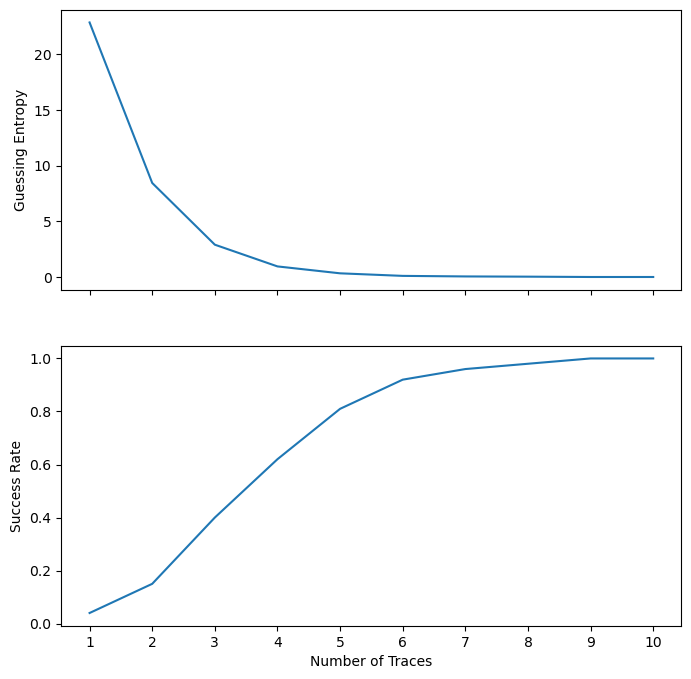

In [27]:
f, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 8))
axs[0].plot(range(1, len(ge)+1), ge)
axs[0].set_ylabel("Guessing Entropy")
axs[1].plot(range(1, len(sr)+1), sr)
axs[1].set_ylabel("Success Rate")
axs[1].set_xlabel("Number of Traces")
axs[1].xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))
axs[1].xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
plt.plot()

Epoch 1/40
2400/2400 [==============================] - 13s 4ms/step - loss: 5.5869 - accuracy: 0.0057 - val_loss: 5.4758 - val_accuracy: 0.0060
Epoch 2/40
2400/2400 [==============================] - 10s 4ms/step - loss: 5.0291 - accuracy: 0.0153 - val_loss: 4.6548 - val_accuracy: 0.0239
Epoch 3/40
2400/2400 [==============================] - 10s 4ms/step - loss: 4.5508 - accuracy: 0.0249 - val_loss: 4.5164 - val_accuracy: 0.0260
Epoch 4/40
2400/2400 [==============================] - 10s 4ms/step - loss: 4.3989 - accuracy: 0.0282 - val_loss: 4.4114 - val_accuracy: 0.0276
Epoch 5/40
2400/2400 [==============================] - 10s 4ms/step - loss: 4.3342 - accuracy: 0.0295 - val_loss: 4.4328 - val_accuracy: 0.0272
Epoch 6/40
2400/2400 [==============================] - 10s 4ms/step - loss: 4.3110 - accuracy: 0.0299 - val_loss: 4.3563 - val_accuracy: 0.0300
Epoch 7/40
2400/2400 [==============================] - 10s 4ms/step - loss: 4.2824 - accuracy: 0.0295 - val_loss: 4.3335 - val_ac

  0%|          | 0/10 [00:00<?, ?it/s]

key hypothesis with highest log-likelihood: 202, correct key: 202


run:   0%|          | 0/100 [00:00<?, ?it/s]

attack:   0%|          | 0/10 [00:00<?, ?it/s]

...

attack:   0%|          | 0/10 [00:00<?, ?it/s]

attack:   0%|          | 0/10 [00:00<?, ?it/s]

attack:   0%|          | 0/10 [00:00<?, ?it/s]

attack:   0%|          | 0/10 [00:00<?, ?it/s]

[]

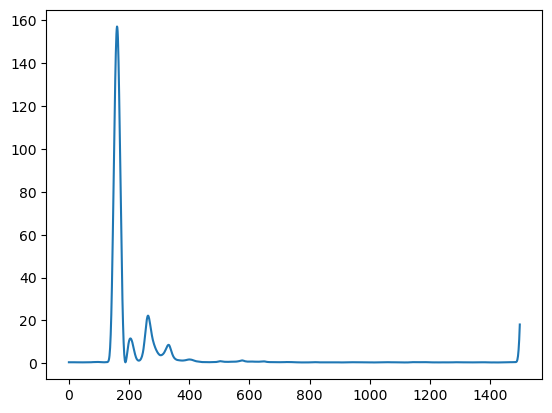

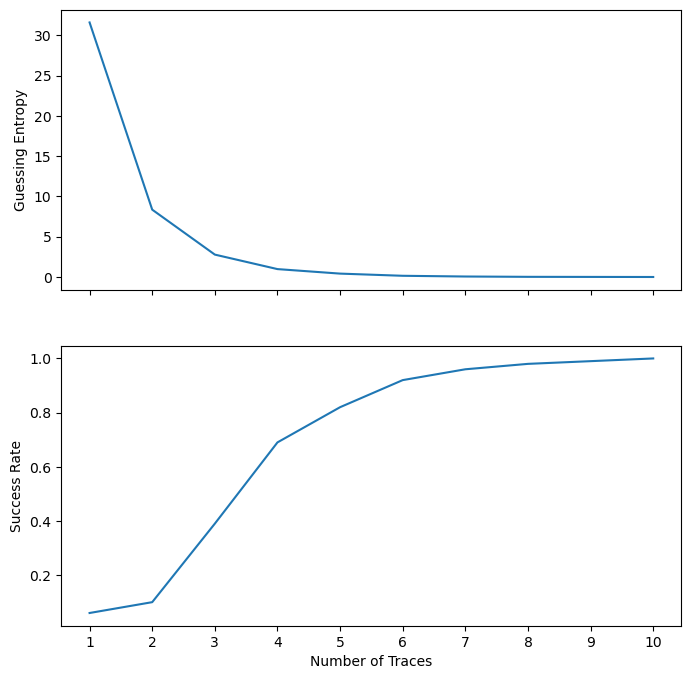

In [28]:
#----------------------------------------------------------------ID IMPLEMENTATON------------------------------ 
#exercise: rewrite the code (you can copy and paste it below if you want to preserve the original) to be in the ID leakage model

attack_byte = 0
#--------------------------
with h5py.File('/kaggle/input/pinata-sca/AES_PTv2_Pinata.h5', "r") as in_file:
    traces_prof = np.array(in_file["Pinata/MS1/Profiling/Traces"])
    traces_attack = np.array(in_file["Pinata/MS1/Attack/Traces"])
    
    pt_prof = np.array(in_file["Pinata/MS1/Profiling/MetaData"]['plaintext'])
    pt_attack = np.array(in_file["Pinata/MS1/Attack/MetaData"]['plaintext'])
    
    key_prof = np.array(in_file["Pinata/MS1/Profiling/MetaData"]['key'])
    key_attack = np.array(in_file["Pinata/MS1/Attack/MetaData"]['key'])
#--------------------------------
# the implementation is masked, but is it done correctly?
#no, there is a huge spike of snr,the trace is still correlated with the intermedian value
plt.plot(snr(sbox[pt_prof[:,attack_byte] ^ key_prof[:,attack_byte]], traces_prof))
#-------------------------------
import tensorflow as tf
from keras import layers
from keras.utils import to_categorical
import tensorflow_addons as tfa

with tf.device("GPU"):
    start = layers.Input(shape=(1500, 1))

    # Convolution layer
    x = layers.Conv1D(8, 16, kernel_initializer='he_uniform',
                      activation='selu', padding='same')(start)
    x = layers.MaxPool1D(2, strides=2)(x)
    x = layers.BatchNormalization()(x)

    # Flatten for dense layers
    x = layers.Flatten()(x)

    # Dense layers
    x = layers.Dense(400, kernel_initializer='he_uniform',
                     activation='selu')(x)

    x = layers.Dense(50, kernel_initializer='he_uniform',
                    activation='selu')(x)
    
    # Classification layer
    end = layers.Dense(256, activation='softmax', name='predictions')(x)
    #end = layers.Dense(9, activation='softmax',
                       #name='predictions')(x)

    clr = tfa.optimizers.CyclicalLearningRate(initial_learning_rate=1e-5,
        maximal_learning_rate=1e-2,
        scale_fn=lambda x: 1/(2.**(x-1)),
        step_size=2 * traces_prof.shape[0]
    )
    model = tf.keras.models.Model(start, end)
    model.compile(loss='categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(clr),
                  metrics=['accuracy'])
#-----------------------------
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
#---------------------------------
tf.debugging.set_log_device_placement(True)
with tf.device('GPU'):
    model.fit(x=traces_prof, y=to_categorical(sbox[pt_prof[:, attack_byte] ^ key_prof[:, attack_byte]]), #chaged to use id and not hw
                  batch_size=50, verbose=1,
                  epochs=40,
                  shuffle=True,
                  callbacks=[early_stopping],
                  validation_split=0.2,
             )
#------------------------------
# predict probabilities and calculate log
predictions = model.predict(traces_attack)
predictions = np.log(predictions + 1e-20)
#----------------------------
key_vector = np.zeros(256)

for i in tqdm(range(10)):
    for kguess in range(256):
        hypothesis = sbox[pt_attack[i, attack_byte] ^ kguess] # Changed to use ID directly
        key_vector[kguess] += predictions[i, hypothesis]
        
print(f"key hypothesis with highest log-likelihood: {np.argmax(key_vector)}, correct key: {key_attack[0][attack_byte]}")
#------------------------------------

def random_subset(size, *a):
    """
    Takes a random subset of size :size: from the given arrays. Makes sure that the rows of the arrays still match after shuffling.
    Example usage: subset_train, subset_labels = random_subset(10, training_set, training_labels)

    :size: size of the subset
    :*a: arrays to take subset of
    """
    combined = list(zip(*a))
    random.shuffle(combined)
    b = [np.array(i)[:size] for i in zip(*combined)]

    return b

def ge_sr(traces, plaintext, key, byte, model, success_cutoff, nr_attack_traces, averaging_nr, track=False, data_augment=None):
    """
    Returns (guessing entropy, success rate) tuple of the given model over the given traces

    :traces: all available attacking traces
    :plaintext: all corresponding plaintext
    :key: the real key
    :byte: byte of key to attack
    :model: model used for making predictions
    :success_cutoff: cutoff to calculate success rate (key rank < success_cutoff)
    :nr_attack_traces: number of traces to use for attacking
    :averaging_nr: number of times to perform attack on subtraces in order to calculate the guessing entropy and success rate
    :track: boolean to indicate whether the guessing entropy should be tracked for each trace amount up to :nr_attack_traces:
    :data_augment: Default None. If not None, should be a function which takes traces as input and returns the augmented traces.
    """

    if track:
        key_ranks = np.zeros((averaging_nr, nr_attack_traces))
        successes = np.zeros((averaging_nr, nr_attack_traces))
    else:
        key_ranks = np.zeros((averaging_nr))
        successes = np.zeros((averaging_nr))

    for run in tqdm(range(averaging_nr), desc="run", leave=False):
        # take a random subset from the attacking traces
        attack_traces, attack_plaintext = random_subset(
            nr_attack_traces, traces, plaintext)

        if data_augment:
            print(f"applying data augmentation")
            attack_traces = data_augment(attack_traces)

        # make predictions: probability of each label, where label = sbox[plt[byte] ^ key[byte]]
        predictions = model(attack_traces, training=False)

        # convert probability to log values
        predictions = np.log(predictions+1e-20)
        _, leakage_mdl = predictions.shape
            
        # set the key probabilities to 0 for each key hypothesis
        key_probabilities = np.zeros(256)

        # for each trace, add up the log(probability) of each key hypothesis
        for i in tqdm(range(nr_attack_traces), desc='attack', leave=False):
            for k in range(256):
                key_probabilities[k] += predictions[i, sbox[attack_plaintext[i, byte] ^ k]]  # always use id case

            # if tracking per trace, then add to key_ranks and successes array here
            if track:
                # now key_probabilities contains estimated key probability after i traces
                key_rank = list(np.argsort(key_probabilities)
                                [::-1]).index(key[byte])
                success = int(key_rank < success_cutoff)

                key_ranks[run, i] = key_rank
                successes[run, i] = success

        # if not tracking per trace, only add to key_ranks and successes array after all traces are attacked
        if not track:
            # now key_probabilities contains the estimated key probability of each key after the full attack
            # argsort()[::-1] -> sorts key values from most likely to least likely. Then get index of actual key byte to get the key rank.
            key_rank = list(np.argsort(key_probabilities)
                            [::-1]).index(key[byte])

            success = int(key_rank < success_cutoff)

            key_ranks[run] = key_rank
            successes[run] = success

    return np.mean(key_ranks, axis=0), np.mean(successes, axis=0)
#-----------------------------------------
ge, sr = ge_sr(traces_attack, pt_attack, key_attack[0], byte=attack_byte, model=model, success_cutoff=1,nr_attack_traces=10,averaging_nr=100, track=True)
#-----------------------------------------
f, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 8))
axs[0].plot(range(1, len(ge)+1), ge)
axs[0].set_ylabel("Guessing Entropy")
axs[1].plot(range(1, len(sr)+1), sr)
axs[1].set_ylabel("Success Rate")
axs[1].set_xlabel("Number of Traces")
axs[1].xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))
axs[1].xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
plt.plot()

# ASCAD dataset

In [30]:
def read_data(file_loc, raw=False):
    """
    Reads in the ASCAD h5 dataset from the given dir_loc. If raw = False, reads ASCAD.h5 and assumes the simplified dataset structure.
    If raw = True, reads ATMega8515_raw_traces.h5 and assumes the raw traces dataset structure.
    Returns the tuple: (x_train, x_test, plt_train, plt_test, keys_train, keys_test)
    :dir_loc: directory where the ASCAD dataset is located. Default = 'F:\\ASCAD\\ATMEGA_AES_v1\\ATM_AES_v1_fixed_key\\ASCAD_data\\ASCAD_databases\\'
    :data_name: Dataset name. Default = 'ASCAD.h5'
    """
    with h5py.File(file_loc, "r") as in_file:
        # Load traces
        x_train = np.array(
            in_file['Profiling_traces/traces'], dtype=np.int8)
        x_test = np.array(in_file['Attack_traces/traces'], dtype=np.int8)
        # labels are sbox(plt[2] XOR key[2])

        labels_train = np.array(in_file['Profiling_traces/labels'])
        labels_test = np.array(in_file['Attack_traces/labels'])

        plt_train = np.array(
            in_file['Profiling_traces/metadata']['plaintext'])
        plt_test = np.array(in_file['Attack_traces/metadata']['plaintext'])

        keys_train = np.array(in_file['Profiling_traces/metadata']['key'])
        keys_test = np.array(in_file['Attack_traces/metadata']['key'])

        masks_train = np.array(in_file['Profiling_traces/metadata']['masks'])
        masks_test = np.array(in_file['Attack_traces/metadata']['masks'])

        return x_train, x_test, labels_train, labels_test, plt_train, plt_test, keys_train, keys_test, masks_train, masks_test

In [31]:
# load in data
# this dataset is synchronized, try to build a model to perform an attack!
x_train, x_test, labels_train, labels_test, plt_train, plt_test, keys_train, keys_test, masks_train, masks_test = read_data('/kaggle/input/ascad-fixed-key/Base_desync0.h5')

The 14 first elements of the mask array correspond to the masks r[3],··· ,r[16] in Algorithm 1 and the two last elements respectively correspond to r_in and r_out (the masks r [1] and r[2] have been forced to 0 for test/validation purpose)

You can find information about the dataset in the corresponding paper [here](https://link.springer.com/article/10.1007/s13389-019-00220-8)

In [32]:
# labels here are the output of the sbox of byte 2, i.e.
attack_byte = 2
np.all(sbox[plt_train[:,attack_byte] ^ keys_train[:,attack_byte]] == labels_train)

True

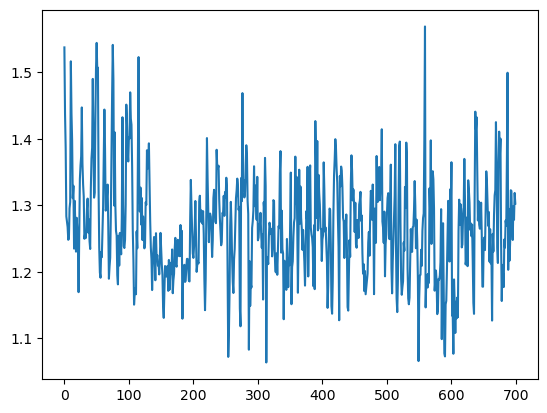

In [33]:
plt.plot(snr(sbox[plt_train[:,attack_byte] ^ keys_train[:,attack_byte]],x_train))

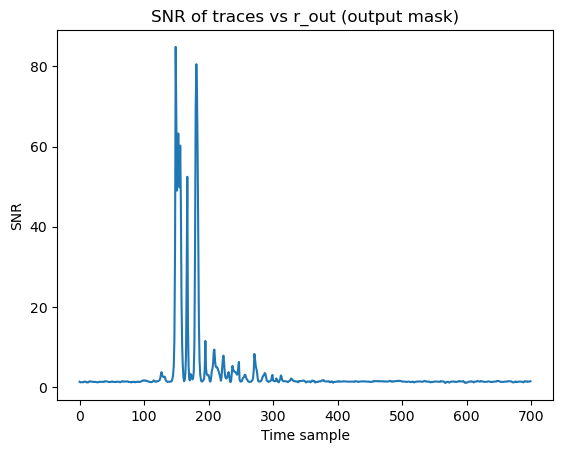

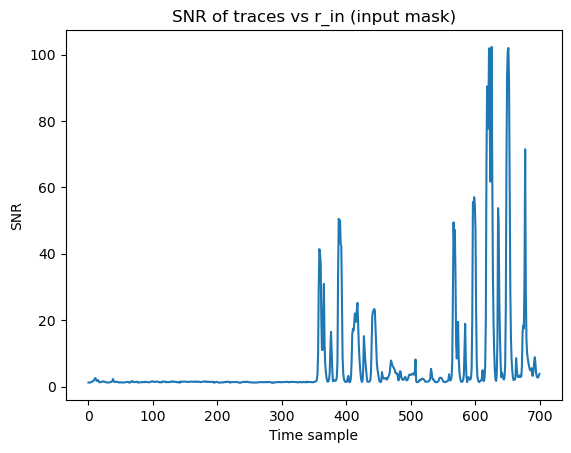

In [35]:
# it doesn't seem like the sbox output leaks..
# exercise: check if the masks leak

plt.plot(snr(masks_train[:, -1], x_train))
plt.title("SNR of traces vs r_out (output mask)")
plt.xlabel("Time sample")
plt.ylabel("SNR")
plt.show()

plt.plot(snr(masks_train[:, -2], x_train))
plt.title("SNR of traces vs r_in (input mask)")
plt.xlabel("Time sample")
plt.ylabel("SNR")
plt.show()

Sbox(PT+key+r_in)+r-out
The power consumption depends heavily on the value of r_out and r_in during certain period of time.
The masking itself is not hidden and can be exploited to perform attacks!

In [25]:
# exercise: break the ASCAD dataset! You can use any kind of model, preprocessing, etc. you like, but keep the profiling - attack seperation

From class I knew that CNN are the prime choice for this kind of task, so I relied on those. However several configurations can be followed and going through a proper hyperparameter optimization blind would be quite daunting (I've tried but my CNN, inspired by yours, wasn't learning). A quick dip in the scientific literature showed that until 2018 hyp. configuration of CNNs capable of breaking ASCAD wasn't pubblic. However [this](https://eprint.iacr.org/2018/053) paper had the info I was searching. It is also available on [Paperswithcode](https://paperswithcode.com/paper/deep-learning-for-side-channel-analysis-and) with their own [implementation](https://github.com/ANSSI-FR/ASCAD/blob/master/ASCAD_train_models.py) which was useful to get infos about the structure and hyperparameters. On the other hand I'd also like to keep the network smaller if I can, so that I can deliver faster ;). <- Said by a very naive myself before clashing with nothing of this working whatsoever, but this material was still useful to me

In [65]:
x_shape = (x_train.shape[1], 1) 
y_train = to_categorical(labels_train, num_classes=256)
y_test = to_categorical(labels_test, num_classes=256)

In [61]:
#def preprocess_data(x_train, x_test):
    
 #   x_train = x_train.astype(np.float32).reshape(x_train.shape[0], x_train.shape[1], 1)
 #   x_test = x_test.astype(np.float32).reshape(x_test.shape[0], x_test.shape[1], 1)
    # normalize
 #   mean = np.mean(x_train, axis=0, keepdims=True)
 #   std = np.std(x_train, axis=0, keepdims=True) + 1e-8 # avoid division by 0
 #   x_train = (x_train - mean) / std
 #   x_test = (x_test - mean) / std
    
  #  return x_train, x_test

In [67]:

x_train = x_train.astype(np.float32).reshape(x_train.shape[0], x_train.shape[1], 1)
x_test = x_test.astype(np.float32).reshape(x_test.shape[0], x_test.shape[1], 1)

# normalize
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0) + 1e-10  # avoid division by 0

x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

In [ ]:
#cropping so we cut part of the noisy useless data? idk im trying
#x_train = x_train[:, 150:250]
#x_test = x_test[:, 150:250]
#x_shape = (x_train.shape[1], 1)
#not working

In [69]:
#@copy pasted for simplicity
def random_subset(size, *a):
    """
    Takes a random subset of size :size: from the given arrays. Makes sure that the rows of the arrays still match after shuffling.
    Example usage: subset_train, subset_labels = random_subset(10, training_set, training_labels)

    :size: size of the subset
    :*a: arrays to take subset of
    """
    combined = list(zip(*a))
    random.shuffle(combined)
    b = [np.array(i)[:size] for i in zip(*combined)]

    return b

def ge_sr(traces, plaintext, key, byte, model, success_cutoff, nr_attack_traces, averaging_nr, track=False, data_augment=None):
    """
    Returns (guessing entropy, success rate) tuple of the given model over the given traces

    :traces: all available attacking traces
    :plaintext: all corresponding plaintext
    :key: the real key
    :byte: byte of key to attack
    :model: model used for making predictions
    :success_cutoff: cutoff to calculate success rate (key rank < success_cutoff)
    :nr_attack_traces: number of traces to use for attacking
    :averaging_nr: number of times to perform attack on subtraces in order to calculate the guessing entropy and success rate
    :track: boolean to indicate whether the guessing entropy should be tracked for each trace amount up to :nr_attack_traces:
    :data_augment: Default None. If not None, should be a function which takes traces as input and returns the augmented traces.
    """

    if track:
        key_ranks = np.zeros((averaging_nr, nr_attack_traces))
        successes = np.zeros((averaging_nr, nr_attack_traces))
    else:
        key_ranks = np.zeros((averaging_nr))
        successes = np.zeros((averaging_nr))

    for run in tqdm(range(averaging_nr), desc="run", leave=False):
        # take a random subset from the attacking traces
        attack_traces, attack_plaintext = random_subset(
            nr_attack_traces, traces, plaintext)

        if data_augment:
            print(f"applying data augmentation")
            attack_traces = data_augment(attack_traces)

        # make predictions: probability of each label, where label = sbox[plt[byte] ^ key[byte]]
        predictions = model(attack_traces, training=False)

        # convert probability to log values
        predictions = np.log(predictions+1e-20)
        _, leakage_mdl = predictions.shape
            
        # set the key probabilities to 0 for each key hypothesis
        key_probabilities = np.zeros(256)

        # for each trace, add up the log(probability) of each key hypothesis
        for i in tqdm(range(nr_attack_traces), desc='attack', leave=False):
            for k in range(256):
                if leakage_mdl == 9:
                    key_probabilities[k] += predictions[i, HW[sbox[attack_plaintext[i, byte] ^ k]]]
                else:
                    key_probabilities[k] += predictions[i, sbox[attack_plaintext[i, byte] ^ k]]

            # if tracking per trace, then add to key_ranks and successes array here
            if track:
                # now key_probabilities contains estimated key probability after i traces
                key_rank = list(np.argsort(key_probabilities)
                                [::-1]).index(key[byte])
                success = int(key_rank < success_cutoff)

                key_ranks[run, i] = key_rank
                successes[run, i] = success

        # if not tracking per trace, only add to key_ranks and successes array after all traces are attacked
        if not track:
            # now key_probabilities contains the estimated key probability of each key after the full attack
            # argsort()[::-1] -> sorts key values from most likely to least likely. Then get index of actual key byte to get the key rank.
            key_rank = list(np.argsort(key_probabilities)
                            [::-1]).index(key[byte])

            success = int(key_rank < success_cutoff)

            key_ranks[run] = key_rank
            successes[run] = success

    return np.mean(key_ranks, axis=0), np.mean(successes, axis=0)

In [88]:
#----------------overfitting and used mostly for degbugging--------------
def deep_cnn(input_shape , num_classes=256, learning_rate=0.00001):
    inputs = Input(shape=input_shape)

    x = Conv1D(filters=64, kernel_size=11, padding='same')(inputs) 
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling1D(pool_size=2, strides=2)(x)

    x = Conv1D(filters=128, kernel_size=11, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling1D(pool_size=2, strides=2)(x)
    
    x = Conv1D(filters=256, kernel_size=11, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling1D(pool_size=2, strides=2)(x)

    x = Conv1D(filters=512, kernel_size=11, padding='same')(x) 
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling1D(pool_size=2, strides=2)(x)

    x = Conv1D(filters=512, kernel_size=11, padding='same')(x) 
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling1D(pool_size=2, strides=2)(x)
    
    x = Flatten()(x)
    #x = GlobalAveragePooling1D()(x) #using this over flatten drastically reduce the n of parameters but this isnt working idk removed
    x = Dense(4096, activation='relu')(x)
    x = Dense(4096, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate), #went for adam insted of RMSprop as I'm more used to it/like it more (it isnt working)
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [ ]:
#-------------- this one is not really learning nor i managed to change anything from the core idea of using a much more streamlined CNN to make it work and not overfit-----------------------
def lighter_cnn(input_shape, num_classes=256, learning_rate=0.001):
    inputs = Input(shape=input_shape)
    
    x = Conv1D(32, kernel_size=5, strides=1, padding='same')(inputs) #i ve reduced the filters size 
    x = BatchNormalization()(x)
    x = Activation('selu')(x)
    x = AveragePooling1D(pool_size=2, strides=1)(x)
    
    x = Conv1D(64, kernel_size=5, strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('selu')(x)
    x = AveragePooling1D(pool_size=2, strides=1)(x)

    x = Conv1D(128, kernel_size=5, strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('selu')(x)
    x = AveragePooling1D(pool_size=2, strides=1)(x)

    x = Flatten()(x)
    x = Dense(400, activation='selu')(x)
    x = Dropout(0.5)(x)
    x = Dense(50, activation='selu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

The following is my best attempt, obtained by trying several possible configurations and crucially adding dropout and using RMSprop. Most specs were choosen by trial and error. An important improvement was obtained by using an high number of filters of the dense layers, as using lower numbers proved inefficient. Validation accuracy is however still low.

In [93]:
def thiswillwork_cnn(input_shape, num_classes=256, learning_rate=0.0005):
    
    inputs = Input(shape=input_shape)
    

    x = Conv1D(filters=64, kernel_size=11, padding='same', 
               kernel_regularizer=l2(1e-5))(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling1D(pool_size=2, strides=2)(x)
    x = Dropout(0.1)(x)
    
    x = Conv1D(filters=128, kernel_size=11, padding='same',
               kernel_regularizer=l2(1e-5))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling1D(pool_size=2, strides=2)(x)
    x = Dropout(0.1)(x)
    
    x = Conv1D(filters=256, kernel_size=11, padding='same',
               kernel_regularizer=l2(1e-5))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling1D(pool_size=2, strides=2)(x)
    x = Dropout(0.2)(x)
    
    x = Conv1D(filters=512, kernel_size=11, padding='same',
               kernel_regularizer=l2(1e-5))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling1D(pool_size=2, strides=2)(x)
    x = Dropout(0.2)(x)
    
    x = Flatten()(x)
    x = Dense(1024, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.5)(x)
    x = Dense(1024, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.5)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    # this time i ll use RMSprop
    model.compile(optimizer=RMSprop(learning_rate=learning_rate), 
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [94]:

model = thiswillwork_cnn(input_shape=x_shape)
model.summary()

Model: "model_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 700, 1)]          0         
                                                                 
 conv1d_25 (Conv1D)          (None, 700, 64)           768       
                                                                 
 batch_normalization_25 (Bat  (None, 700, 64)          256       
 chNormalization)                                                
                                                                 
 activation_23 (Activation)  (None, 700, 64)           0         
                                                                 
 average_pooling1d_23 (Avera  (None, 350, 64)          0         
 gePooling1D)                                                    
                                                                 
 dropout_22 (Dropout)        (None, 350, 64)           0   

In [95]:
y_train_cat = to_categorical(labels_train, num_classes=256) #need cat for softmax
y_test_cat  = to_categorical(labels_test, num_classes=256)

In [96]:
history = model.fit(
    x_train, y_train_cat,
    batch_size=200,
    epochs=70,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-4, restore_best_weights=True)],
    verbose=1
)

Epoch 1/70
225/225 [==============================] - 17s 64ms/step - loss: 5.9279 - accuracy: 0.0045 - val_loss: 5.8165 - val_accuracy: 0.0044
Epoch 2/70
225/225 [==============================] - 14s 62ms/step - loss: 5.7991 - accuracy: 0.0048 - val_loss: 5.7817 - val_accuracy: 0.0042
Epoch 3/70
225/225 [==============================] - 14s 62ms/step - loss: 5.7667 - accuracy: 0.0050 - val_loss: 5.7514 - val_accuracy: 0.0044
Epoch 4/70
225/225 [==============================] - 14s 62ms/step - loss: 5.7367 - accuracy: 0.0048 - val_loss: 5.7246 - val_accuracy: 0.0038
Epoch 5/70
225/225 [==============================] - 14s 62ms/step - loss: 5.7130 - accuracy: 0.0051 - val_loss: 5.7025 - val_accuracy: 0.0044
Epoch 6/70
225/225 [==============================] - 14s 62ms/step - loss: 5.6923 - accuracy: 0.0050 - val_loss: 5.6850 - val_accuracy: 0.0044
Epoch 7/70
225/225 [==============================] - 14s 62ms/step - loss: 5.6723 - accuracy: 0.0048 - val_loss: 5.6660 - val_accuracy:

In [ ]:
# exercise: validate you can break the ASCAD dataset
# calculate the guessing entropy and the success rate when using the attack / test traces

In [97]:
attack_byte = 2
ge, sr = ge_sr(
    x_test, plt_test, keys_test[0],
    byte=attack_byte,
    model=model,
    success_cutoff=1,
    nr_attack_traces=50,
    averaging_nr=100,
)
print(f"Guessing entropy is {ge} \nSuccess rate {sr}")

run:   0%|          | 0/100 [00:00<?, ?it/s]

attack:   0%|          | 0/50 [00:00<?, ?it/s]

attack:   0%|          | 0/50 [00:00<?, ?it/s]

attack:   0%|          | 0/50 [00:00<?, ?it/s]

attack:   0%|          | 0/50 [00:00<?, ?it/s]

...

attack:   0%|          | 0/50 [00:00<?, ?it/s]

attack:   0%|          | 0/50 [00:00<?, ?it/s]

attack:   0%|          | 0/50 [00:00<?, ?it/s]

attack:   0%|          | 0/50 [00:00<?, ?it/s]

Guessing entropy is 8.24 
Success rate 0.2


These performances are not optimal but are usable. SR .2 means that for each 5 attacks one manage to get the attacked bit of the key, which is enough to considerably reduce keyspace.